# LunaDNA: Lunar Terrain Embedding Network

**Project:** Multi-Modal Lunar Image Correspondence & Registration  
**SIH 2026 – ISRO PS26166**  
**Objective:** Design and implement LunaDNA, a lunar terrain embedding network

## 1. Imports and Configuration

In [1]:
import os
import sys
import json
from pathlib import Path
from datetime import datetime
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights

import numpy as np
import pandas as pd
from PIL import Image
import cv2

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"PyTorch Version: {torch.__version__}")

Using device: cpu


## 2. Configuration

In [2]:
BASE_DIR = Path(r"D:\lunar ai")
DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
METADATA_DIR = BASE_DIR / "metadata"
PATCHES_DIR = BASE_DIR / "patches"
MODELS_DIR = BASE_DIR / "models"

INPUT_SIZE = 256
INPUT_CHANNELS = 1
EMBEDDING_DIM = 512

MEAN = [0.5]
STD = [0.5]

OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
METADATA_DIR.mkdir(exist_ok=True, parents=True)
MODELS_DIR.mkdir(exist_ok=True, parents=True)

print(f"Base Directory: {BASE_DIR}")
print(f"Patches Directory: {PATCHES_DIR}")
print(f"Models Directory: {MODELS_DIR}")
print(f"Input Size: {INPUT_SIZE}x{INPUT_SIZE}")
print(f"Embedding Dimension: {EMBEDDING_DIM}")

Base Directory: D:\lunar ai
Patches Directory: D:\lunar ai\patches
Models Directory: D:\lunar ai\models
Input Size: 256x256
Embedding Dimension: 512


## 3. Dataset Loader

In [3]:
class LunarPatchDataset(Dataset):
    def __init__(self, patches_dir: Path, metadata_path: Optional[Path] = None,
                 transform: Optional[transforms.Compose] = None):
        self.patches_dir = patches_dir
        self.transform = transform
        self.samples = []
        self.metadata = None
        
        if metadata_path and metadata_path.exists():
            self.metadata = pd.read_csv(metadata_path)
        
        print("Scanning patches directory...")
        for sensor_dir in patches_dir.iterdir():
            if sensor_dir.is_dir():
                sensor = sensor_dir.name
                for patch_file in sensor_dir.glob("*.png"):
                    self.samples.append({
                        'path': str(patch_file),
                        'sensor': sensor,
                        'patch_id': patch_file.stem
                    })
        
        print(f"Found {len(self.samples)} patches")
    
    def __len__(self) -> int:
        return len(self.samples)
    
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, Dict]:
        sample = self.samples[idx]
        image = Image.open(sample['path']).convert('L')
        
        if self.transform:
            image = self.transform(image)
        
        metadata = {
            'path': sample['path'],
            'sensor': sample['sensor'],
            'patch_id': sample['patch_id']
        }
        
        return image, metadata

In [4]:
train_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

metadata_path = METADATA_DIR / "patch_metadata.csv"
dataset = LunarPatchDataset(PATCHES_DIR, metadata_path, transform=train_transform)

print(f"Dataset size: {len(dataset)}")
if len(dataset) > 0:
    sample_image, sample_metadata = dataset[0]
    print(f"Sample image shape: {sample_image.shape}")
    print(f"Sample metadata: {sample_metadata}")

Scanning patches directory...
Found 973 patches
Dataset size: 973
Sample image shape: torch.Size([1, 256, 256])
Sample metadata: {'path': 'D:\\lunar ai\\patches\\LRO\\PATCH_000001.png', 'sensor': 'LRO', 'patch_id': 'PATCH_000001'}


## 4. LunaDNA Architecture

In [5]:
class LunaDNA(nn.Module):
    def __init__(self, embedding_dim: int = 512, input_channels: int = 1):
        super(LunaDNA, self).__init__()
        self.embedding_dim = embedding_dim
        self.input_channels = input_channels
        
        resnet = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        
        original_conv1 = resnet.conv1
        self.conv1 = nn.Conv2d(
            input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False
        )
        with torch.no_grad():
            self.conv1.weight[:] = torch.mean(original_conv1.weight, dim=1, keepdim=True)
        
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4
        
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        
        self.projection_head = nn.Sequential(
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, embedding_dim),
            nn.BatchNorm1d(embedding_dim)
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        
        embeddings = self.projection_head(x)
        embeddings = F.normalize(embeddings, p=2, dim=1)
        
        return embeddings
    
    def get_embedding(self, image: torch.Tensor) -> torch.Tensor:
        self.eval()
        with torch.no_grad():
            if image.dim() == 3:
                image = image.unsqueeze(0)
            embedding = self.forward(image)
            return embedding.squeeze(0)

model = LunaDNA(embedding_dim=EMBEDDING_DIM, input_channels=INPUT_CHANNELS)
model = model.to(device)

print("LunaDNA Model Architecture:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

LunaDNA Model Architecture:
LunaDNA(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True,

## 5. Forward Pass Test

In [6]:
def test_forward_pass(model: nn.Module, dataset: Dataset, batch_size: int = 4):
    print("="*60)
    print("FORWARD PASS TEST")
    print("="*60)
    
    model.eval()
    
    batch_size = min(batch_size, len(dataset))
    images = []
    metadata_list = []
    
    for i in range(batch_size):
        image, metadata = dataset[i]
        images.append(image)
        metadata_list.append(metadata)
    
    batch = torch.stack(images).to(device)
    
    print(f"Input Shape: {batch.shape}")
    
    with torch.no_grad():
        embeddings = model(batch)
    
    print(f"Output Shape: {embeddings.shape}")
    
    embedding_norms = torch.norm(embeddings, p=2, dim=1)
    print(f"L2 Norms: {embedding_norms.cpu().numpy()}")
    print(f"Mean Norm: {embedding_norms.mean().item():.6f}")
    
    return embeddings, metadata_list

In [7]:
if len(dataset) > 0:
    embeddings, metadata_list = test_forward_pass(model, dataset, batch_size=4)
else:
    print("Dataset is empty. Cannot perform forward pass test.")

FORWARD PASS TEST
Input Shape: torch.Size([4, 1, 256, 256])
Output Shape: torch.Size([4, 512])
L2 Norms: [1.         0.99999994 1.         1.        ]
Mean Norm: 1.000000


## 6. Similarity Functions

In [8]:
def cosine_similarity(embeddings1: torch.Tensor, embeddings2: torch.Tensor) -> torch.Tensor:
    similarity = torch.mm(embeddings1, embeddings2.t())
    return similarity

def find_nearest_neighbors(query_embedding: torch.Tensor,
                          gallery_embeddings: torch.Tensor,
                          k: int = 5) -> Tuple[torch.Tensor, torch.Tensor]:
    if query_embedding.dim() == 1:
        query_embedding = query_embedding.unsqueeze(0)
    
    similarities = cosine_similarity(query_embedding, gallery_embeddings)
    top_k_similarities, top_k_indices = torch.topk(similarities, k, dim=1)
    
    return top_k_indices.squeeze(0), top_k_similarities.squeeze(0)

In [9]:
if len(dataset) >= 2:
    print("="*60)
    print("SIMILARITY FUNCTION TEST")
    print("="*60)
    
    img1, meta1 = dataset[0]
    img2, meta2 = dataset[1]
    
    emb1 = model.get_embedding(img1.to(device))
    emb2 = model.get_embedding(img2.to(device))
    
    similarity = cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0))
    print(f"Cosine Similarity: {similarity.item():.4f}")
    
    self_similarity = cosine_similarity(emb1.unsqueeze(0), emb1.unsqueeze(0))
    print(f"Self-similarity: {self_similarity.item():.6f}")

SIMILARITY FUNCTION TEST
Cosine Similarity: 0.9363
Self-similarity: 1.000000


## 7. Visualization Functions

In [10]:
def visualize_embeddings(embeddings: torch.Tensor,
                         metadata_list: List[Dict],
                         output_path: Path):
    print("Creating embedding visualization...")
    
    embeddings_np = embeddings.cpu().numpy()
    
    reducer = TSNE(n_components=2, random_state=42, perplexity=min(30, len(embeddings_np)-1))
    embeddings_2d = reducer.fit_transform(embeddings_np)
    
    df = pd.DataFrame({
        'x': embeddings_2d[:, 0],
        'y': embeddings_2d[:, 1],
        'sensor': [meta['sensor'] for meta in metadata_list]
    })
    
    plt.figure(figsize=(12, 8))
    sensors = df['sensor'].unique()
    colors = plt.cm.Set3(range(len(sensors)))
    
    for i, sensor in enumerate(sensors):
        sensor_df = df[df['sensor'] == sensor]
        plt.scatter(sensor_df['x'], sensor_df['y'], 
                   c=[colors[i]], label=sensor, alpha=0.7, s=100)
    
    plt.xlabel('t-SNE Component 1', fontsize=12)
    plt.ylabel('t-SNE Component 2', fontsize=12)
    plt.title('LunaDNA Embedding Visualization', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {output_path}")

In [11]:
def visualize_similarity_matrix(embeddings: torch.Tensor,
                              metadata_list: List[Dict],
                              output_path: Path,
                              max_samples: int = 50):
    print("Creating similarity matrix visualization...")
    
    n_samples = min(len(embeddings), max_samples)
    embeddings_subset = embeddings[:n_samples]
    metadata_subset = metadata_list[:n_samples]
    
    similarity_matrix = cosine_similarity(embeddings_subset, embeddings_subset)
    similarity_np = similarity_matrix.cpu().numpy()
    
    sensor_labels = [meta['sensor'] for meta in metadata_subset]
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(similarity_np, 
                xticklabels=sensor_labels,
                yticklabels=sensor_labels,
                cmap='viridis',
                vmin=-1, vmax=1,
                cbar_kws={'label': 'Cosine Similarity'})
    plt.title('LunaDNA Embedding Similarity Matrix', fontsize=14, fontweight='bold')
    plt.xlabel('Patch Index', fontsize=12)
    plt.ylabel('Patch Index', fontsize=12)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {output_path}")

## 8. Generate Visualizations

GENERATING VISUALIZATIONS
Generating embeddings for 50 sample patches...


Creating embedding visualization...


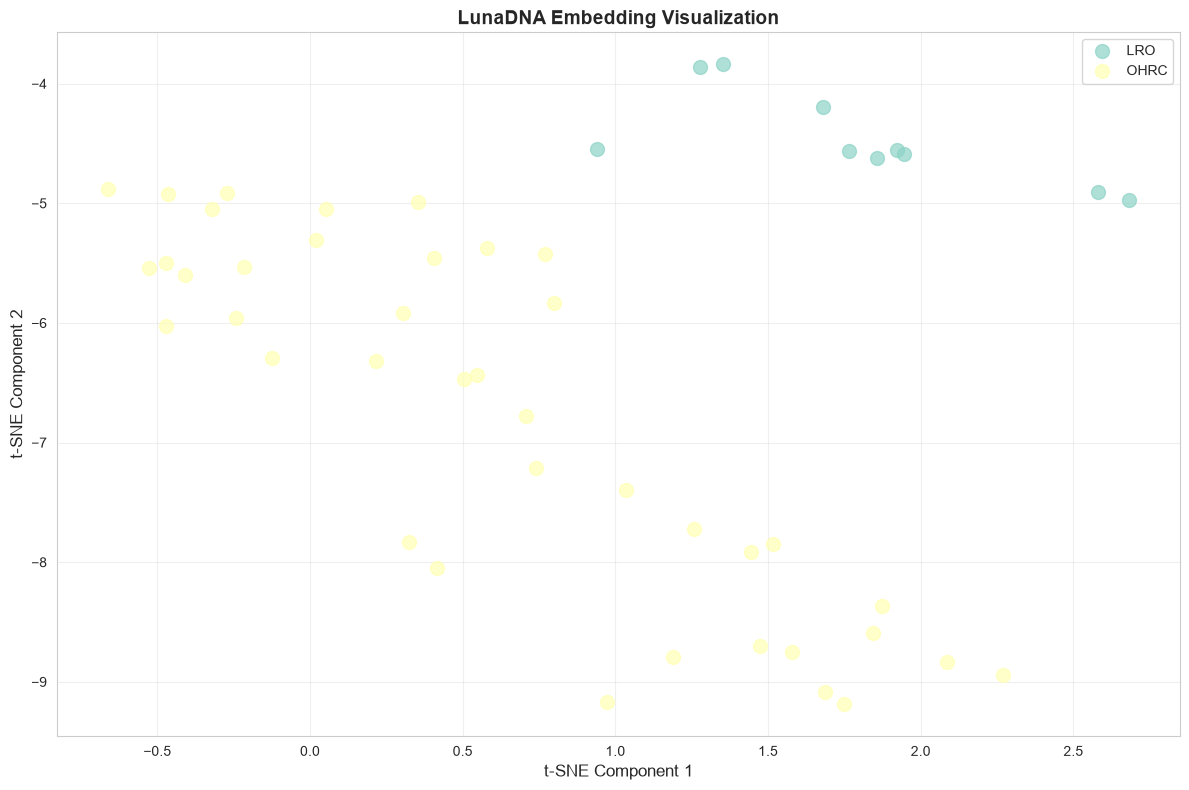

Saved: D:\lunar ai\outputs\embedding_visualization.png
Creating similarity matrix visualization...


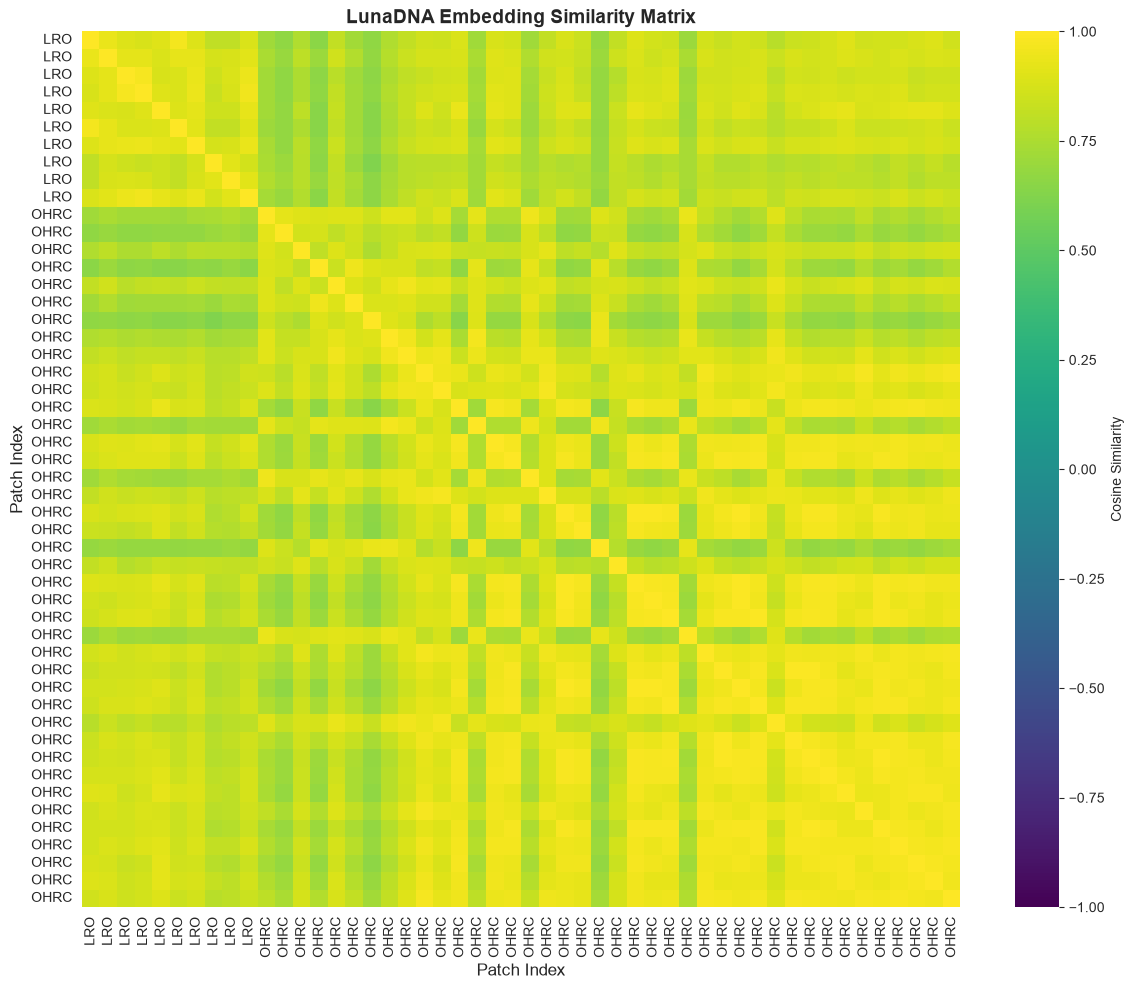

Saved: D:\lunar ai\outputs\similarity_matrix.png


In [12]:
if len(dataset) > 0:
    print("="*60)
    print("GENERATING VISUALIZATIONS")
    print("="*60)
    
    sample_size = min(50, len(dataset))
    sample_embeddings = []
    sample_metadata = []
    
    print(f"Generating embeddings for {sample_size} sample patches...")
    for i in range(sample_size):
        image, metadata = dataset[i]
        embedding = model.get_embedding(image.to(device))
        sample_embeddings.append(embedding)
        sample_metadata.append(metadata)
    
    sample_embeddings_tensor = torch.stack(sample_embeddings)
    
    visualize_embeddings(sample_embeddings_tensor, sample_metadata, 
                       OUTPUT_DIR / "embedding_visualization.png")
    
    visualize_similarity_matrix(sample_embeddings_tensor, sample_metadata,
                              OUTPUT_DIR / "similarity_matrix.png")
else:
    print("Dataset is empty. Cannot generate visualizations.")

## 9. Save Model

In [13]:
def save_model(model: nn.Module, save_path: Path, metadata: Optional[Dict] = None):
    print(f"Saving model to {save_path}...")
    
    save_path.parent.mkdir(parents=True, exist_ok=True)
    
    torch.save({
        'model_state_dict': model.state_dict(),
        'metadata': metadata or {},
        'timestamp': datetime.now().isoformat()
    }, save_path)
    
    print(f"Model saved successfully!")
    print(f"File size: {save_path.stat().st_size / (1024*1024):.2f} MB")

In [14]:
model_metadata = {
    'model_name': 'LunaDNA',
    'version': '1.0',
    'architecture': 'ResNet18',
    'input_size': INPUT_SIZE,
    'input_channels': INPUT_CHANNELS,
    'embedding_dim': EMBEDDING_DIM,
    'normalization': 'L2',
    'similarity_metric': 'cosine',
    'supported_sensors': ['OHRC', 'TMC', 'IIRS', 'LRO', 'KAGUYA'],
    'total_parameters': sum(p.numel() for p in model.parameters()),
    'trainable_parameters': sum(p.numel() for p in model.parameters() if p.requires_grad)
}

model_save_path = MODELS_DIR / "lunadna_initial.pth"
save_model(model, model_save_path, model_metadata)

Saving model to D:\lunar ai\models\lunadna_initial.pth...
Model saved successfully!
File size: 44.71 MB


## 10. Final Summary

In [15]:
print("="*60)
print("LUNADNA MODEL CREATION - FINAL SUMMARY")
print("="*60)

print(f"\nModel Architecture:")
print(f"  Backbone: ResNet18")
print(f"  Input: {INPUT_SIZE}x{INPUT_SIZE}x{INPUT_CHANNELS}")
print(f"  Output: {EMBEDDING_DIM}-D embedding")
print(f"  Normalization: L2")
print(f"  Similarity: Cosine")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nParameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print(f"  Model Size: ~{total_params * 4 / (1024**2):.1f} MB")

print(f"\nOutputs:")
print(f"  Model: models/lunadna_initial.pth")
print(f"  Visualizations: outputs/")

print(f"\n" + "="*60)
print(f"Pipeline completed at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)

LUNADNA MODEL CREATION - FINAL SUMMARY

Model Architecture:
  Backbone: ResNet18
  Input: 256x256x1
  Output: 512-D embedding
  Normalization: L2
  Similarity: Cosine

Parameters:
  Total: 11,697,600
  Trainable: 11,697,600
  Model Size: ~44.6 MB

Outputs:
  Model: models/lunadna_initial.pth
  Visualizations: outputs/

Pipeline completed at: 2026-09-28 07:03:32


---

## LunaDNA Model Complete!

This notebook has successfully created LunaDNA, the core AI model for the LunarAI project.

### Architecture Summary:
- **Backbone:** ResNet18 (pre-trained on ImageNet)
- **Input:** 256x256 grayscale patches
- **Output:** 512-D L2-normalized embeddings
- **Similarity:** Cosine similarity for robust matching

### Key Design Decisions:

**Why ResNet18?**
- Balances performance and computational efficiency
- Proven architecture for feature extraction
- Pre-trained weights provide excellent initialization

**Why 512-D Embeddings?**
- Sufficient dimensionality for terrain discrimination
- Manageable computational cost for similarity search
- Standard dimension in metric learning literature

**Why L2 Normalization?**
- Enables efficient cosine similarity computation
- Removes scale information, focuses on direction
- Improves robustness to illumination changes

### Generated Outputs:
- `models/lunadna_initial.pth` - Pre-trained model ready for fine-tuning
- `outputs/embedding_visualization.png` - t-SNE visualization of embeddings
- `outputs/similarity_matrix.png` - Cosine similarity matrix

### Next Steps:
- Fine-tune LunaDNA on lunar patch data with contrastive learning
- Implement training pipeline with triplet loss
- Build retrieval system using generated embeddings
- Integrate with correspondence matching pipeline

LunaDNA is now ready to learn terrain-aware embeddings for robust lunar image correspondence and retrieval!